# 4. Modelo SARIMAX
El modelo SARIMAX (Seasonal ARIMA with eXogenous regressors) es una extensión del modelo SARIMA que incorpora, además de los componentes autorregresivos, de media móvil y estacionales, la posibilidad de incluir variables exógenas o predictoras externas. Se expresa como:

SARIMAX(p,d,q)(P,D,Q,s)

donde:

(p,d,q) representan los componentes no estacionales y (P,D,Q) representan los componentes estacionales.

s indica el periodo de la estacionalidad (por ejemplo, 24 para datos horarios diarios).

y adicionalmente, X representa el conjunto de variables exógenas que se incorporan al modelo.

La principal ventaja de SARIMAX frente a SARIMA es su capacidad para mejorar la predicción al incorporar información adicional relevante, como pueden ser variables temporales (día de la semana, mes...) u otras variables explicativas que influyen en la serie objetivo.

C:\Users\NITROPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\NITROPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Optimization terminated successfully.
         Current function value: 3.649696
         Iterations: 4
         Function evaluations: 1110
                                      SARIMAX Results                                      
Dep. Variable:                               price   No. Observations:                35040
Model:             SARIMAX(2, 0, 1)x(2, 1, [], 24)   Log Likelihood             -127885.344
Date:                             Wed, 02 Sep 2026   AIC                         255834.688
Time:                                     13:46:50   BIC                         256105.522
Sample:                                 01-02-2020   HQIC                        255920.953
                                      - 12-31-2023                                         
Covariance Type:                               opg                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

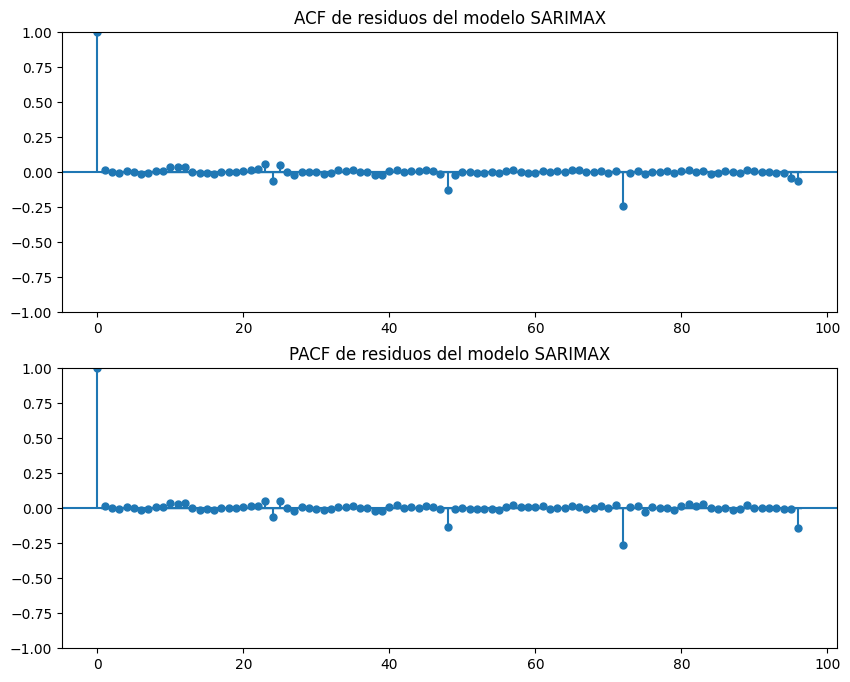


TEST LJUNG-BOX
      lb_stat     lb_pvalue
10  77.375493  1.637751e-12
los residuos NO son ruido blanco (tienen estructura/autocorrelacion)

========== MÉTRICAS DE PRECISIÓN ==========
  MAE   (Error Absoluto Medio):        38.4259 €/MWh
  RMSE  (Raíz Error Cuadrático Medio): 45.2982 €/MWh
  MAPE  (Error Porcentual Medio):       1219973416925284096.00%
  R²    (Coeficiente determinación):    0.0273
  RMSE modelo naive (benchmark):        12.8171 €/MWh
  El modelo es PEOR que el naive



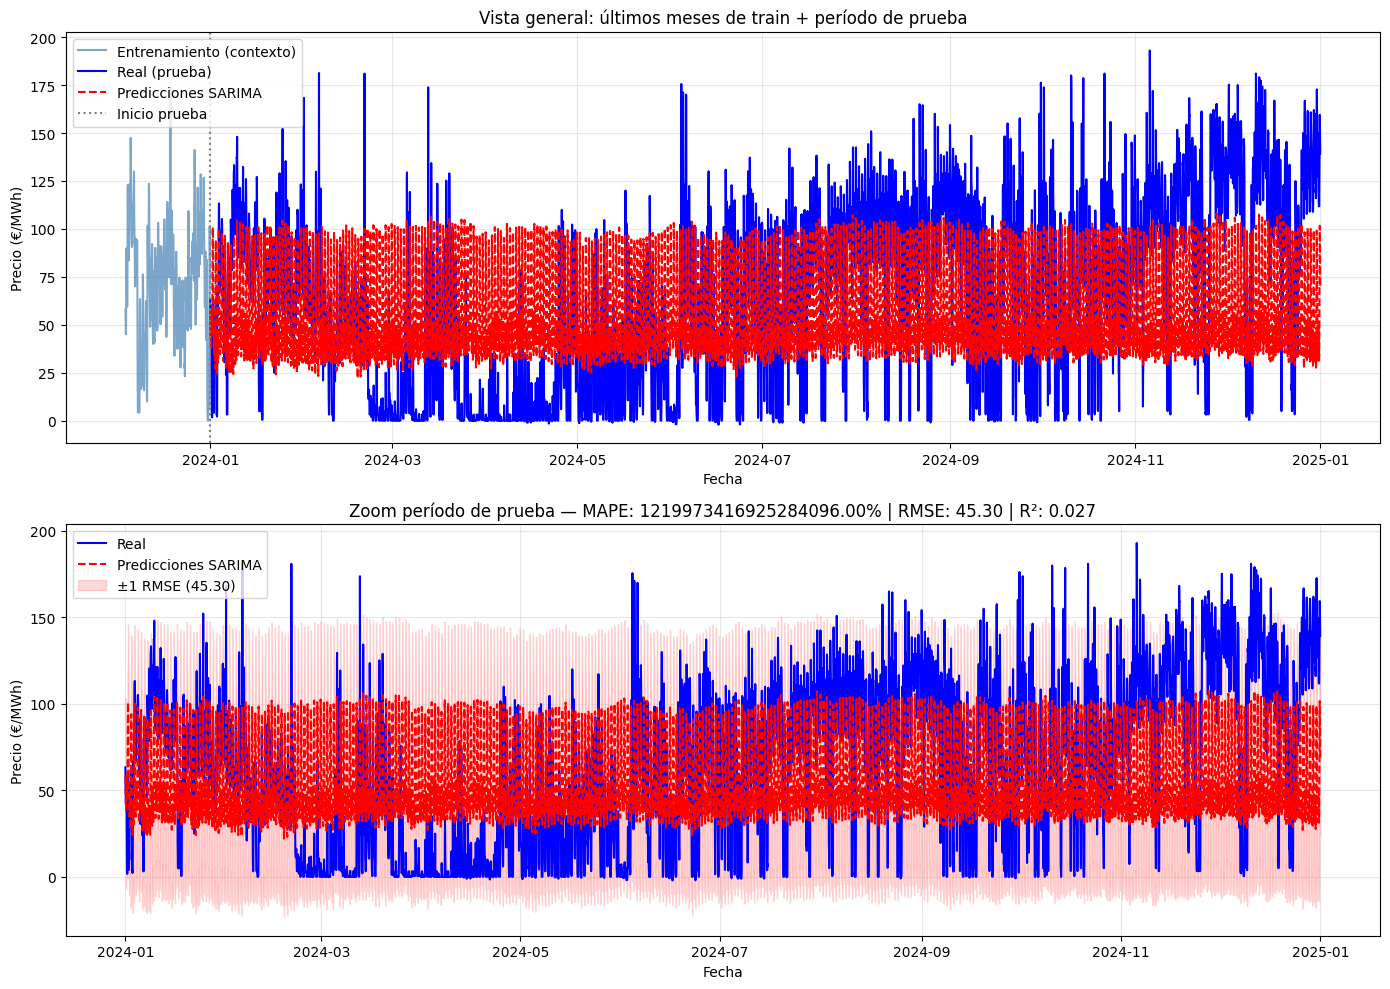


¡Archivo 'predicciones_sarimax_2024.csv' generado con éxito!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


# =======================================================================================
# LECTURA DEL SUPERDATASET (de precios horarios de la electricidad, generacion y climatología)
# =======================================================================================
df_dummy = pd.read_csv('../../../Dataset_Unificado/Dataset_Unificado1.csv', sep=';')
df_dummy['datetime'] = pd.to_datetime(df_dummy['datetime'])
df_dummy.set_index('datetime', inplace=True) 
# A partir de aquí, 'datetime' ya no es una columna

# =======================================================================================
# 0. DESPLAZAMIENTO DE VARIABLES (SHIFT 24H) PARA EVITAR DATA LEAKAGE
# =======================================================================================
# 1. Identificamos qué columnas NO se deben desplazar (las del calendario actual y el precio a predecir)
cols_temporales = ['year', 'month', 'day', 'hour', 'dayofweek', 'is_weekend']
target = 'price'

# 2. Identificamos las exógenas (todas las demás: demanda, generación, clima...)
cols_exogenas = [col for col in df_dummy.columns if col not in cols_temporales and col != target]

# 3. Desplazamos las variables exógenas 24 posiciones (24 horas)
df_dummy[cols_exogenas] = df_dummy[cols_exogenas].shift(24)

# Creamos una variable nueva: "El precio que hubo hace 24 horas". 
df_dummy['price_lag24'] = df_dummy['price'].shift(24)
# Suele ser el predictor más potente en mercados eléctricos.

# 5. SACRIFICAMOS EL PRIMER DÍA: Empezamos explícitamente el 2 de enero de 2020
# Como 'datetime' es el índice, podemos filtrar usando strings de fecha directamente
df_dummy = df_dummy.loc['2020-01-02':] 

# Por seguridad, si hubiera algún otro NaN en el dataset original, lo eliminamos
df_dummy = df_dummy.dropna()

# =======================================================================================
# 1. PREPARACIÓN Y DIVISIÓN TEMPORAL
# =======================================================================================
X = df_dummy.drop(columns=['price'])
y = df_dummy['price']

# División cronológica estricta: entrenar con 2020-2023, validar con 2024 completo
X_train, X_test = X[(X['year'] < 2024)], X[X['year'] == 2024]
y_train, y_test = y[(X['year'] < 2024)], y[X['year'] == 2024]

# Eliminamos 'year' de los predictores
X_train = X_train.drop(columns=['year'])
X_test = X_test.drop(columns=['year'])

# Variables categóricas temporales identificadas
cat_features = ['hour', 'month', 'dayofweek', 'is_weekend']
for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# ==============================
# 5. Elegir los órdenes p y q del modelo SARIMA
# ==============================
# En Box-Jenkins a partir de los gráficos de ACF y PACF, elegimos p y q
# En nuestro caso fueron p=2 y q=1
# En ARIMA, el orden es (p, d, q).
# El valor d e sel numero de diferenciaciones para hacer la serie estacionaria,
#  pero como la serie ya es estacionaria, no es necesario diferenciar (d=0)
#  aunque se puede poner d=1 sin que cambie el resultado matemático porque
#  ARIMA con d=1 en una serie ya estacionaria es equivalente a ARMA con d=0
p, d, q = 2, 0, 1           # parte no estacional (igual que ARIMA/ARMA)
P, D, Q, s = 2, 1, 0, 24    # parte estacional 


# drop calendar columns from X_train/X_test first
cols_to_drop = ['year', 'month', 'day', 'dayofweek', 'hour', 'is_weekend']
X_train = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in cols_to_drop if c in X_test.columns])

# Paso 1: aislar el efecto — quita price_lag24 y deja solo el AR estacional
X_train_v2 = X_train.drop(columns=['price_lag24'])
X_test_v2 = X_test.drop(columns=['price_lag24'])

X_train = X_train_v2
X_test = X_test_v2

modelo_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=True,
    enforce_invertibility=True
)


# Ajustar el modelo
modelo_ajustado = modelo_sarimax.fit(
    method='powell',
    maxiter=200,       # 100 antes, pero a veces no converge con tan pocas iteraciones
    # low_memory=True,
    # cov_type='none',   # skip expensive Hessian — add back once you're happy with the model
    cov_type='opg',# mucho más barato que el Hessiano, pero te da inferencia real
    
    disp=True          # so you can watch it actually iterate, not hang silently
)

# Mostrar un resumen del modelo
print(modelo_ajustado.summary())


# ==============================
# 5.2. Verificar residuos (validación)
# ==============================

# Verificar residuos (validación)
residuos = modelo_ajustado.resid

# Gráfico ACF de residuos
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(residuos, ax=axes[0], lags=96)
axes[0].set_title('ACF de residuos del modelo SARIMAX')

plot_pacf(residuos, ax=axes[1], lags=96)
axes[1].set_title('PACF de residuos del modelo SARIMAX')
plt.savefig('sarimax_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# Prueba de Ljung-Box (si p-value > 0.05 los residuos son ruido blanco)
lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(f"\nTEST LJUNG-BOX")
print(lb_test.to_string())
if (lb_test['lb_pvalue'] > 0.05).all():
    print("los residuos son ruido blanco")
else:
    print("los residuos NO son ruido blanco (tienen estructura/autocorrelacion)")

# ==============================
# 6. Predecir los valores del conjunto de prueba
# ==============================
# forecast recibe el número de pasos a predecir y las variables exógenas del conjunto de prueba

#predicciones = modelo_ajustado.forecast(steps=48, exog=X_test)
predicciones = modelo_ajustado.forecast(steps=len(y_test), exog=X_test)
predicciones.index = y_test.index   # para que luego se pueda gaficar bien

# ==============================
# 7. AMPLIADA - Métricas de precisión
# ==============================
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae  = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
mape = mean_absolute_percentage_error(y_test, predicciones) * 100

# Métrica adicional: R² (qué % de varianza explica el modelo)
ss_res = np.sum((y_test - predicciones) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Naive benchmark: predecir siempre el valor anterior (lag-1)
naive_pred = y_test.shift(1).dropna()
rmse_naive = np.sqrt(mean_squared_error(y_test[1:], naive_pred))

print("\n========== MÉTRICAS DE PRECISIÓN ==========")
print(f"  MAE   (Error Absoluto Medio):        {mae:.4f} €/MWh")
print(f"  RMSE  (Raíz Error Cuadrático Medio): {rmse:.4f} €/MWh")
print(f"  MAPE  (Error Porcentual Medio):       {mape:.2f}%")
print(f"  R²    (Coeficiente determinación):    {r2:.4f}")
print(f"  RMSE modelo naive (benchmark):        {rmse_naive:.4f} €/MWh")
print(f"  El modelo es {'MEJOR' if rmse < rmse_naive else 'PEOR'} que el naive")
print("============================================\n")

# Guardar metricas en CSV
metricas_df = pd.DataFrame({
    'Metrica': ['MAE', 'RMSE', 'MAPE', 'R2', 'RMSE_Naive'],
    'Valor': [mae, rmse, mape, r2, rmse_naive],
    'Unidad': ['€/MWh', '€/MWh', '%', '', '€/MWh']
})

metricas_df.to_csv('metricas_rendimiento.csv', index=False)

# ==============================
# 8. CORREGIDA - Gráficas con zoom y separadas
# ==============================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Gráfica 1: visión global (últimas 4 semanas de train + todo el test) ---
CONTEXTO = 672  # horas de entrenamiento que se muestran como contexto

ax1 = axes[0]
ax1.plot(y_train[-CONTEXTO:].index, y_train[-CONTEXTO:],
         label='Entrenamiento (contexto)', color='steelblue', alpha=0.7)
ax1.plot(y_test.index, y_test,
         label='Real (prueba)', color='blue', linewidth=1.5)
ax1.plot(y_test.index, predicciones,
         label='Predicciones SARIMA', color='red', linestyle='--', linewidth=1.5)
ax1.axvline(x=y_test.index[0], color='gray', linestyle=':', linewidth=1.5,
            label='Inicio prueba')
ax1.set_title('Vista general: últimos meses de train + período de prueba')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio (€/MWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfica 2: zoom solo en el período de prueba ---
ax2 = axes[1]
ax2.plot(y_test.index, y_test,
         label='Real', color='blue', linewidth=1.5)
ax2.plot(y_test.index, predicciones,
         label='Predicciones SARIMA', color='red', linestyle='--', linewidth=1.5)
ax2.fill_between(y_test.index,
                 predicciones - rmse,
                 predicciones + rmse,
                 alpha=0.15, color='red', label=f'±1 RMSE ({rmse:.2f})')
ax2.set_title(f'Zoom período de prueba — MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | R²: {r2:.3f}')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Precio (€/MWh)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sarima_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()

# =======================================================================================
# 9. EXPORTAR Y GUARDAR RESULTADOS (MODELO SARIMA)
# =======================================================================================
# Creamos un nuevo dataframe para comparar la realidad vs la predicción de SARIMA
df_resultados_sarima = pd.DataFrame({
    'Precio_Real': y_test,
    'Prediccion_SARIMAX': predicciones,
    'Diferencia_SARIMAX': y_test - predicciones
}, index=y_test.index)

# Añadimos variables temporales al dataframe de resultados para agrupar
df_resultados_sarima['hour'] = df_resultados_sarima.index.hour
df_resultados_sarima['month'] = df_resultados_sarima.index.month


# Guardamos los resultados en un archivo CSV específico para SARIMAX
df_resultados_sarima.to_csv('predicciones_sarimax_2024.csv')
print("\n¡Archivo 'predicciones_sarimax_2024.csv' generado con éxito!")


### Visualización de las prediciones en una ventana de tiempo

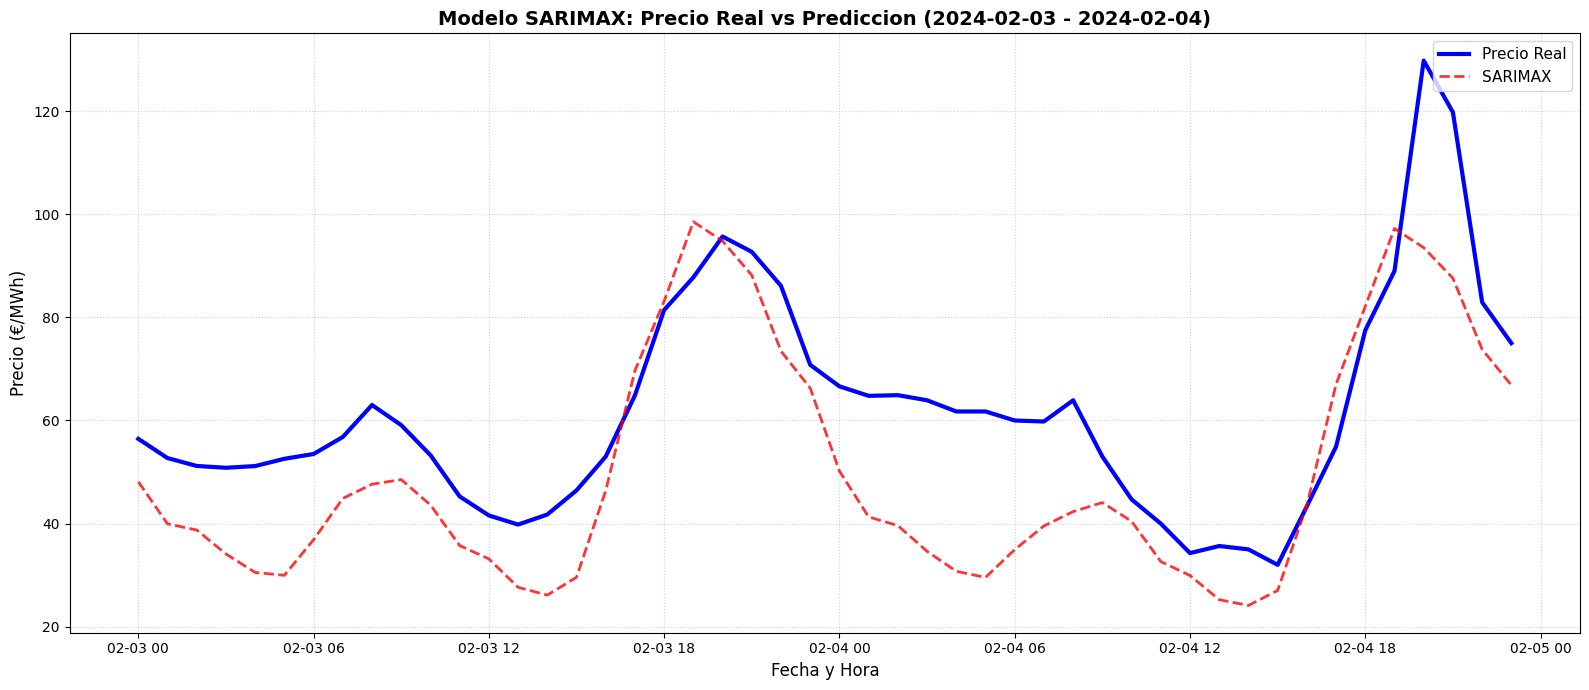

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 7. VISUALIZACION DE RESULTADOS (MODELO SARIMAX)
# =======================================================================================
# Cargamos el archivo de predicciones SARIMAX
df_resultados_csv = pd.read_csv('predicciones_sarimax_2024.csv', index_col=0, parse_dates=True)

# Filtramos un tramo corto (ej. ultima semana de julio 2024)
df_plot = df_resultados_csv.loc['2024-02-03':'2024-02-04']

plt.figure(figsize=(16, 7))

# 1. Linea del Precio Real (Azul, continua y mas gruesa para que destaque)
plt.plot(df_plot.index, df_plot['Precio_Real'], 
         label='Precio Real', color='blue', linewidth=3)

# 2. Linea de Prediccion SARIMAX (Rojo, punteada)
plt.plot(df_plot.index, df_plot['Prediccion_SARIMAX'], 
         label='SARIMAX', color='red', linestyle='--', linewidth=2, alpha=0.8)

# Añadimos titulos y diseño
plt.title('Modelo SARIMAX: Precio Real vs Prediccion (' + str(df_plot.index[0].date()) + ' - ' + str(df_plot.index[-1].date()) + ')', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Precio (€/MWh)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# Guardamos y mostramos
plt.savefig('grafico_sarimax_(' + str(df_plot.index[0].date()) + ' - ' + str(df_plot.index[-1].date()) + ')_2024.png', dpi=300)
plt.show()

#### Gráfica del MAE (error medio)

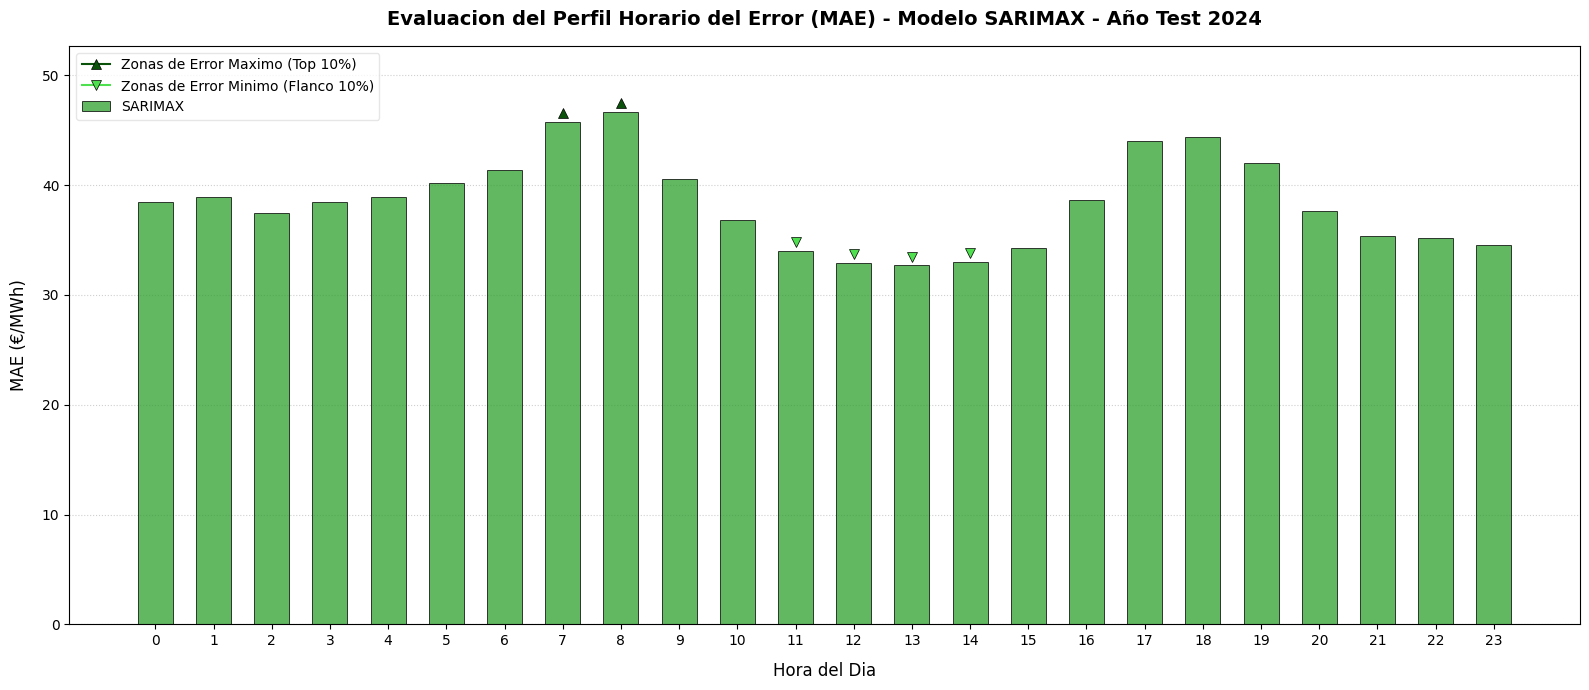

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =======================================================================================
# 8. ANALISIS HORARIO DEL ERROR (MODELO SARIMAX - DESDE CSV)
# =======================================================================================

# 1. Carga y calculo dinamico de metricas por hora
df_resultados_csv = pd.read_csv('predicciones_sarimax_2024.csv', index_col=0, parse_dates=True)
mae_sarimax = df_resultados_csv.groupby('hour').apply(lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_SARIMAX']))

fig, ax = plt.subplots(figsize=(16, 7))

horas = np.arange(24)
ancho_barra = 0.6

# 2. Dibujo de las barras
barras_sarimax = ax.bar(horas, mae_sarimax, width=ancho_barra, label='SARIMAX', color='#2ca02c', alpha=0.75, edgecolor='black', linewidth=0.7)

# ---------------------------------------------------------------------------------------
# IDENTIFICACION Y MARCADO DE ERRORES MAXIMOS Y MINIMOS
# ---------------------------------------------------------------------------------------
max_val = mae_sarimax.max()
min_val = mae_sarimax.min()
rango_total = max_val - min_val

limite_alto = max_val - (0.10 * rango_total)
limite_bajo = min_val + (0.10 * rango_total)

legend_max_added = False
legend_min_added = False

for hora in horas:
    valor_mae = mae_sarimax[hora]
    posicion_x = hora
    
    # Caso A: Errores maximos o en el 10% superior (Flecha hacia arriba '^')
    if valor_mae >= limite_alto:
        label_text = 'Zonas de Error Maximo (Top 10%)' if not legend_max_added else ""
        ax.plot(posicion_x, valor_mae + 0.8, marker='^', color='#0b520b', 
                markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
        legend_max_added = True
        
    # Caso B: Errores minimos o en el 10% inferior (Flecha hacia abajo 'v')
    elif valor_mae <= limite_bajo:
        label_text = 'Zonas de Error Minimo (Flanco 10%)' if not legend_min_added else ""
        ax.plot(posicion_x, valor_mae + 0.8, marker='v', color='#4ee04e', 
                markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
        legend_min_added = True

# ---------------------------------------------------------------------------------------
# DISEÑO, FORMATO Y REJILLA
# ---------------------------------------------------------------------------------------
ax.set_title('Evaluacion del Perfil Horario del Error (MAE) - Modelo SARIMAX - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('MAE (€/MWh)', fontsize=12, labelpad=10)
ax.set_xticks(horas)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Leyenda unificada a la izquierda
ax.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Limites del eje Y holgados para que no se solape con la leyenda
ax.set_ylim(0, mae_sarimax.max() + 6)

plt.tight_layout()

# Guardado automatico
plt.savefig('grafico_error_horario_sarimax_2024.png', dpi=300)
plt.show()

#### Grafica del Error Modal

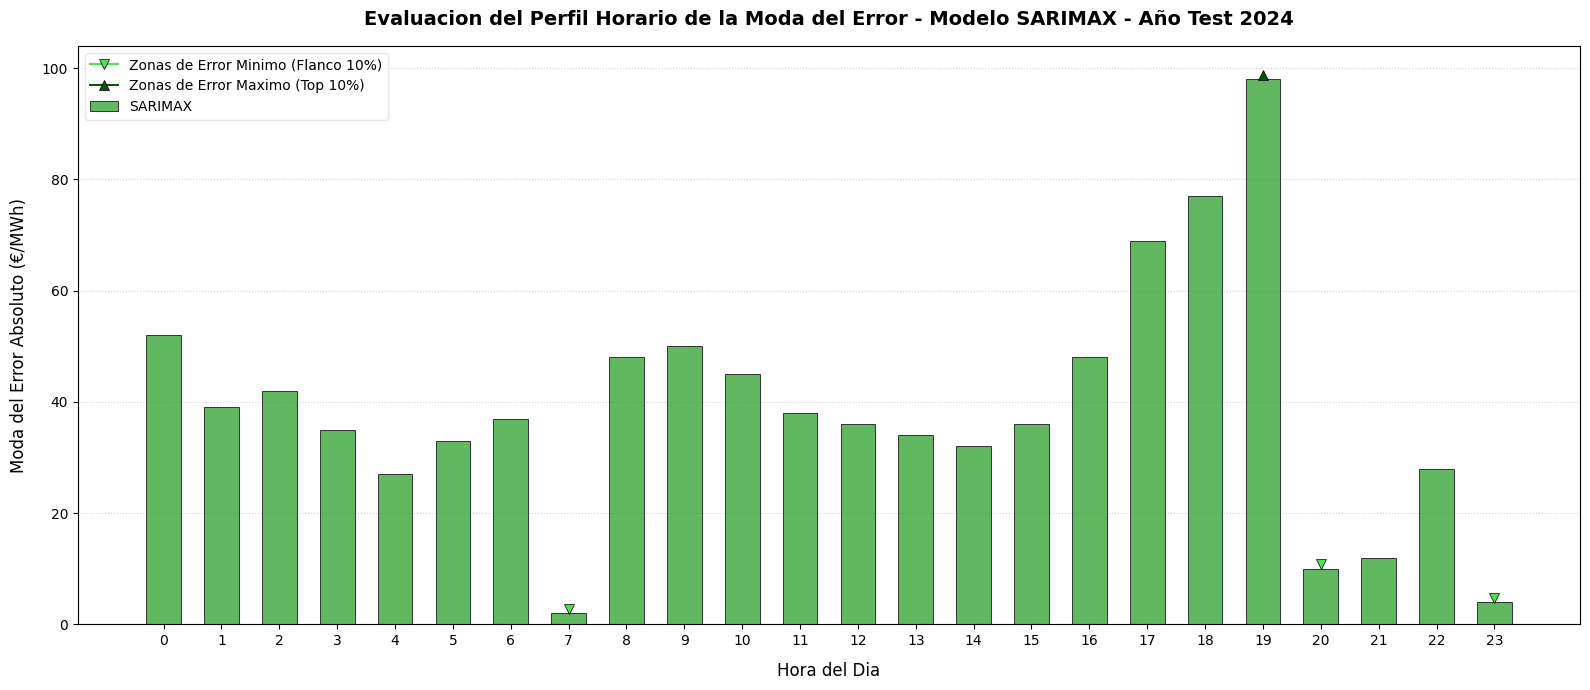

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 8. ANALISIS HORARIO DEL ERROR (MODA DEL ERROR ABSOLUTO - SARIMAX)
# =======================================================================================

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_sarimax_2024.csv', index_col=0, parse_dates=True)

# Funcion interna para calcular la moda del error absoluto redondeado a enteros
def calcular_moda_error(df, col_pred):
    # Calculamos el error absoluto por cada fila
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    # Redondeamos a enteros para permitir que existan valores repetidos (Moda)
    error_redondeado = error_absoluto.round(0)
    # Agrupamos por hora y extraemos el valor mas frecuente (la moda)
    return error_redondeado.groupby(df['hour']).apply(lambda x: x.mode().iloc[0] if not x.empty else 0)

# Calculo dinamico de la moda del error por hora para SARIMAX
moda_sarimax = calcular_moda_error(df_resultados_csv, 'Prediccion_SARIMAX')

fig, ax = plt.subplots(figsize=(16, 7))

horas = np.arange(24)
ancho_barra = 0.6

# 2. Dibujo de las barras base
barras_sarimax = ax.bar(horas, moda_sarimax, width=ancho_barra, label='SARIMAX', color='#2ca02c', alpha=0.75, edgecolor='black', linewidth=0.7)

# ---------------------------------------------------------------------------------------
# IDENTIFICACION Y MARCADO DE ERRORES MAXIMOS Y MINIMOS
# ---------------------------------------------------------------------------------------
max_val = moda_sarimax.max()
min_val = moda_sarimax.min()
rango_total = max_val - min_val

limite_alto = max_val - (0.10 * rango_total)
limite_bajo = min_val + (0.10 * rango_total)

legend_max_added = False
legend_min_added = False

for hora in horas:
    valor_actual = moda_sarimax[hora]
    posicion_x = hora
    
    # Caso A: Valores maximos o en el 10% superior (Flecha hacia arriba '^')
    if valor_actual >= limite_alto:
        label_text = 'Zonas de Error Maximo (Top 10%)' if not legend_max_added else ""
        ax.plot(posicion_x, valor_actual + 0.8, marker='^', color='#0b520b', 
                markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
        legend_max_added = True
        
    # Caso B: Valores minimos o en el 10% inferior (Flecha hacia abajo 'v')
    elif valor_actual <= limite_bajo:
        label_text = 'Zonas de Error Minimo (Flanco 10%)' if not legend_min_added else ""
        ax.plot(posicion_x, valor_actual + 0.8, marker='v', color='#4ee04e', 
                markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
        legend_min_added = True

# ---------------------------------------------------------------------------------------
# DISEÑO, FORMATO Y REJILLA
# ---------------------------------------------------------------------------------------
ax.set_title('Evaluacion del Perfil Horario de la Moda del Error - Modelo SARIMAX - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('Moda del Error Absoluto (€/MWh)', fontsize=12, labelpad=10)
ax.set_xticks(horas)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Leyenda unificada a la izquierda
ax.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Limites del eje Y holgados para que no se solape con la leyenda
ax.set_ylim(0, moda_sarimax.max() + 6)

plt.tight_layout()

# Guardado automatico
plt.savefig('grafico_moda_error_horario_sarimax_2024.png', dpi=300)
plt.show()

#### Gráfica de Errores Extremos

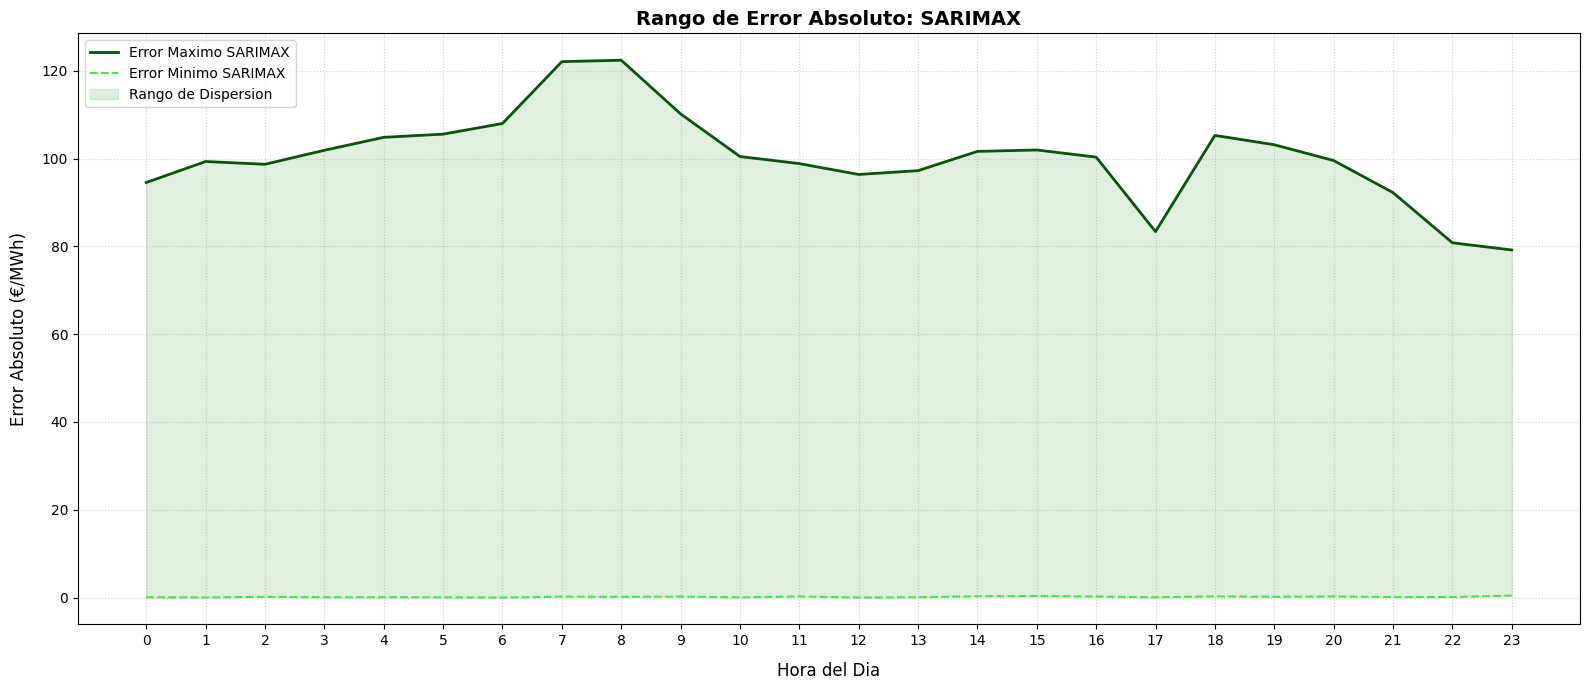

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 9. ANALISIS HORARIO DE ERRORES EXTREMOS (MAXIMOS Y MINIMOS - SARIMAX)
# =======================================================================================

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_sarimax_2024.csv', index_col=0, parse_dates=True)

# Funcion para extraer el error absoluto maximo y minimo por hora
def calcular_errores_extremos(df, col_pred):
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    err_max = error_absoluto.groupby(df['hour']).max()
    err_min = error_absoluto.groupby(df['hour']).min()
    return err_max, err_min

# Calculo dinamico para SARIMAX
max_sarimax, min_sarimax = calcular_errores_extremos(df_resultados_csv, 'Prediccion_SARIMAX')

horas = np.arange(24)

# Creamos una grafica para SARIMAX
fig, ax = plt.subplots(figsize=(16, 7))

# ---------------------------------------------------------------------------------------
# PANEL: SARIMAX (Verde)
# ---------------------------------------------------------------------------------------
ax.plot(horas, max_sarimax, color='#0b520b', linestyle='-', linewidth=2, label='Error Maximo SARIMAX')
ax.plot(horas, min_sarimax, color='#4ee04e', linestyle='--', linewidth=1.5, label='Error Minimo SARIMAX')
ax.fill_between(horas, min_sarimax, max_sarimax, color='#2ca02c', alpha=0.15, label='Rango de Dispersion')
ax.set_title('Rango de Error Absoluto: SARIMAX', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('Error Absoluto (€/MWh)', fontsize=12, labelpad=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=10)

# Configuracion de los ejes
plt.xticks(horas)

plt.tight_layout()

# Guardado automatico
plt.savefig('grafico_errores_extremos_horarios_sarimax_2024.png', dpi=300)
plt.show()

#### Comparativa Gráfica de los datos horarios

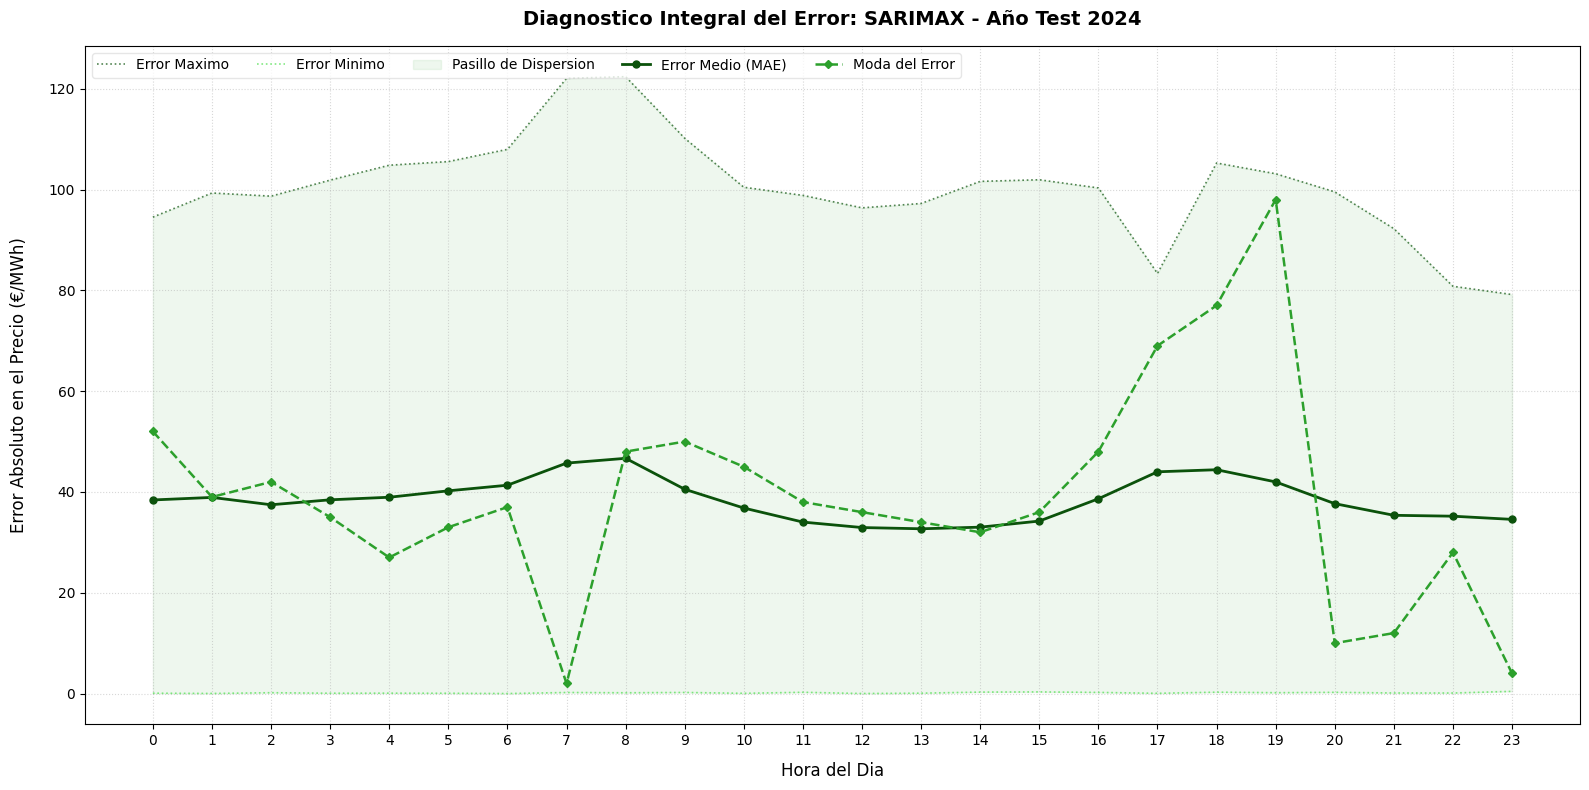

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =======================================================================================
# 10. DIAGNOSTICO INTEGRAL DEL ERROR: MAXIMOS, MINIMOS, MEDIAS Y MODAS (SARIMAX)
# =======================================================================================

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_sarimax_2024.csv', index_col=0, parse_dates=True)

# Funcion para calcular todas las metricas horarias de forma limpia
def calcular_metricas_completas(df, col_pred):
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    
    err_max = error_absoluto.groupby(df['hour']).max()
    err_min = error_absoluto.groupby(df['hour']).min()
    err_mean = error_absoluto.groupby(df['hour']).mean()
    err_mode = error_absoluto.round(0).groupby(df['hour']).apply(lambda x: x.mode().iloc[0] if not x.empty else 0)
    
    return err_max, err_min, err_mean, err_mode

# Calculo dinamico para SARIMAX
max_sarimax, min_sarimax, mean_sarimax, mode_sarimax = calcular_metricas_completas(df_resultados_csv, 'Prediccion_SARIMAX')

horas = np.arange(24)

# Creamos una grafica para SARIMAX
fig, ax = plt.subplots(figsize=(16, 8))

# A. Dibujar el pasillo de dispersion (Maximos y Minimos)
ax.plot(horas, max_sarimax, color='#0b520b', linestyle=':', linewidth=1.2, alpha=0.7, label='Error Maximo')
ax.plot(horas, min_sarimax, color='#4ee04e', linestyle=':', linewidth=1.2, alpha=0.7, label='Error Minimo')
ax.fill_between(horas, min_sarimax, max_sarimax, color='#2ca02c', alpha=0.08, label='Pasillo de Dispersion')

# B. Dibujar el Comportamiento Central (Media y Moda)
# Media (MAE) con linea discontinua y marcadores redondos
ax.plot(horas, mean_sarimax, color='#0b520b', linestyle='-', linewidth=2, 
        marker='o', markersize=5, label='Error Medio (MAE)')

# Moda con linea de guiones y marcadores de diamante
ax.plot(horas, mode_sarimax, color='#2ca02c', linestyle='--', linewidth=1.8, 
        marker='D', markersize=4, label='Moda del Error')

# C. Estetica y formatos
ax.set_title('Diagnostico Integral del Error: SARIMAX - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('Error Absoluto en el Precio (€/MWh)', fontsize=12, labelpad=15)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper left', fontsize=10, ncol=5, frameon=True, facecolor='white', edgecolor='#e0e0e0')

plt.xticks(horas)

plt.tight_layout()

# Guardado automatico
plt.savefig('grafico_diagnostico_integral_errores_sarimax_2024.png', dpi=300)
plt.show()

### Metricas Accuracy

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error
)

# =======================================================================================
# 11. CALCULO DE METRICAS GLOBALES DE PRECISION Y ROBUSTAS (SARIMAX)
# =======================================================================================

# 1. Definicion matematica de funciones porcentuales robustas para el TFG
def calcular_wape(y_true, y_pred):
    """Calcula el Weighted MAPE ponderando por la suma del precio real."""
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

def calcular_smape(y_true, y_pred):
    """Calcula el sMAPE acotando el denominador entre el valor real y el predicho."""
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diferencia = np.abs(y_true - y_pred)
    # Manejo de proteccion por si precio real y predicho coinciden en 0.0 €/MWh
    ratio = np.where(denominador == 0, 0.0, diferencia / denominador)
    return np.mean(ratio) * 100


# 2. Cargar el archivo de predicciones guardado
# Asumimos que 'datetime' es la primera columna y sirve como indice temporal
df = pd.read_csv('predicciones_sarimax_2024.csv', index_col=0, parse_dates=True)

# 3. Definir el modelo SARIMAX y su columna de prediccion correspondiente en el CSV
modelos = {
    'SARIMAX': 'Prediccion_SARIMAX'
}

print("=== METRICAS GLOBALES DE PRECISION (ACCURACY) - AÑO TEST 2024 ===")
resultados = []

# 4. Bucle unificado para calcular TODAS las metricas por cada modelo
for nombre, col_pred in modelos.items():
    # Variables objetivo reales y predichas
    y_true = df['Precio_Real']
    y_pred = df[col_pred]
    
    # Calculo de metricas estandar de Scikit-Learn
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # Formato porcentaje
    medae = median_absolute_error(y_true, y_pred)
    
    # Calculo de metricas porcentuales robustas integradas
    wape_val = calcular_wape(y_true, y_pred)
    smape_val = calcular_smape(y_true, y_pred)
    
    # Calculo del error absoluto y su MODA global (redondeado a 0 decimales)
    error_absoluto = (y_true - y_pred).abs()
    error_redondeado = error_absoluto.round(0)
    # Extrae el primer valor de la moda; si la serie esta vacia asigna 0
    err_mode = error_redondeado.mode().iloc[0] if not error_redondeado.empty else 0.0
    
    # Imprimir por consola de forma limpia y agrupada
    print(f"\n[{nombre}]")
    print(f"  - MAE:       {mae:.3f} €/MWh")
    print(f"  - RMSE:      {rmse:.3f} €/MWh")
    print(f"  - R²:        {r2:.3f}")
    print(f"  - MAPE:      {mape:.2f}%")
    print(f"  - wAPE:      {wape_val:.2f}%")
    print(f"  - sMAPE:     {smape_val:.2f}%")
    print(f"  - MedAE:     {medae:.3f} €/MWh")
    print(f"  - Moda Error:{err_mode:.0f} €/MWh (Redondeado)")
    
    # Guardar todas las metricas redondeadas para el DataFrame final
    resultados.append({
        'Modelo': nombre,
        'MAE (€/MWh)': round(mae, 3),
        'RMSE (€/MWh)': round(rmse, 3),
        'R²': round(r2, 3),
        'MAPE (%)': round(mape, 2),
        'wAPE (%)': round(wape_val, 2),
        'sMAPE (%)': round(smape_val, 2),
        'MedAE (€/MWh)': round(medae, 3),
        'Moda Error (€/MWh)': int(err_mode)
    })

# 5. Guardar una unica tabla resumen limpia para adjuntar a la memoria del TFG
df_resumen = pd.DataFrame(resultados)
df_resumen.to_csv('resumen_metricas_globales_sarimax_2024.csv', index=False)
print("\nArchivo 'resumen_metricas_globales_sarimax_2024.csv' generado con exito")

=== METRICAS GLOBALES DE PRECISION (ACCURACY) - AÑO TEST 2024 ===

[SARIMAX]
  - MAE:       38.426 €/MWh
  - RMSE:      45.298 €/MWh
  - R²:        0.027
  - MAPE:      1219973416925284096.00%
  - wAPE:      60.94%
  - sMAPE:     81.99%
  - MedAE:     36.010 €/MWh
  - Moda Error:32 €/MWh (Redondeado)

Archivo 'resumen_metricas_globales_sarimax_2024.csv' generado con exito


### Representacion del resto de variables de Accurancy

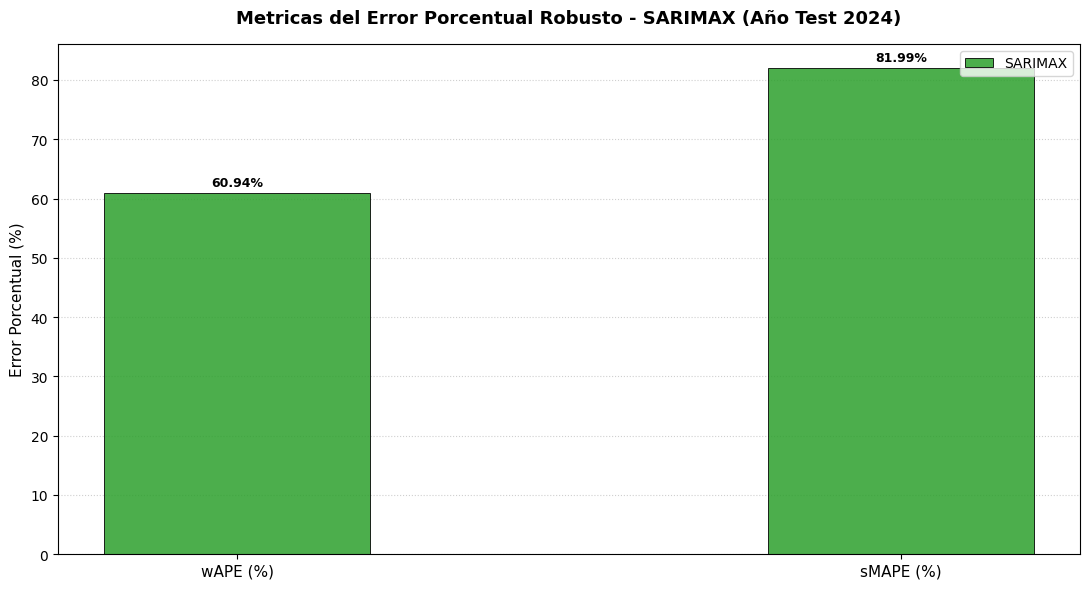

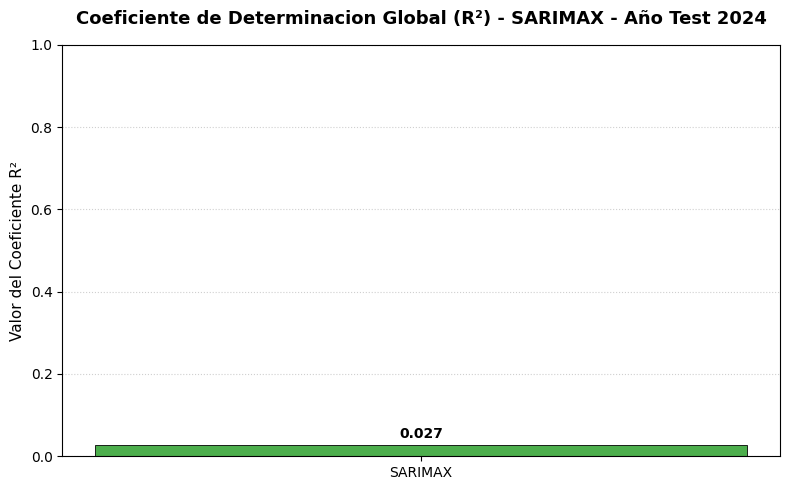

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 12. VISUALIZACION DE METRICAS GLOBALES DE PRECISION (ROBUSTAS - SARIMAX)
# =======================================================================================

# 1. Cargar el dataframe resumen generado en el paso anterior
df_resumen = pd.read_csv('resumen_metricas_globales_sarimax_2024.csv')

# Configuramos los modelos como indice para facilitar el grafico
df_resumen.set_index('Modelo', inplace=True)

# Definimos los colores oficiales para SARIMAX
color_sarimax = '#2ca02c' # Verde

# ---------------------------------------------------------------------------------------
# GRAFICA A: METRICAS PORCENTUALES ROBUSTAS (wAPE vs sMAPE)
# ---------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# Seleccionamos unicamente las metricas que no generan ruido numerico
metricas_pct = ['wAPE (%)', 'sMAPE (%)']
x = np.arange(len(metricas_pct))
ancho_barra = 0.4

# Dibujamos las barras para SARIMAX
ax.bar(x, df_resumen.loc['SARIMAX', metricas_pct], width=ancho_barra, label='SARIMAX', color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.7)

# Formato academico para el analisis porcentual robusto
ax.set_title('Metricas del Error Porcentual Robusto - SARIMAX (Año Test 2024)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Error Porcentual (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metricas_pct, fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.set_axisbelow(True)
ax.legend(loc='upper right', fontsize=10)

# Añadir etiquetas de valor exacto encima de cada barra
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_errores_porcentuales_sarimax_2024.png', dpi=300)
plt.show()

# ---------------------------------------------------------------------------------------
# GRAFICA B: COMPORTAMIENTO DEL R² (BONDAD DE AJUSTE GLOBAL)
# ---------------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))

modelos_nombres = df_resumen.index
r2_valores = df_resumen['R²']

barras_r2 = plt.bar(modelos_nombres, r2_valores, color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.7, width=0.5)

# Formato academico para el R2
plt.title('Coeficiente de Determinacion Global (R²) - SARIMAX - Año Test 2024', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Valor del Coeficiente R²', fontsize=11)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.gca().set_axisbelow(True)

# Añadir el valor exacto encima de cada barra
for bar in barras_r2:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_r2_global_sarimax_2024.png', dpi=300)
plt.show()